In [1]:
# 1. Import các thư viện cần thiết
import pandas as pd
import numpy as np
import pickle
import os
import re
from math import log2
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from tqdm.auto import tqdm

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download('stopwords', quiet=True)
plt.style.use('ggplot')

# Cau hinh thu muc
RAW_DIR = "../data/raw"
PREPROCESSED_DIR = "../data/processed"
MODELS_DIR = "../models"
TV2_OUT = os.path.join(PREPROCESSED_DIR, "tv2")

for directory in [MODELS_DIR, TV2_OUT]:
    os.makedirs(directory, exist_ok=True)

In [2]:
# 2. Tiền xử lý văn bản
port_stemmer = PorterStemmer()
english_stops = set(stopwords.words('english'))

academic_noise = {
    'paper', 'propos', 'method', 'approach', 'result',
    'show', 'base', 'also', 'howev', 'therefor', 'thu',
    'furthermor', 'present', 'work', 'studi', 'experiment', 'evalu'
}

regex_url = re.compile(r'http\S+')
regex_math = re.compile(r'\$.*?\$')
regex_special_chars = re.compile(r'[^a-z0-9\s]')
regex_multi_space = re.compile(r'\s+')

def clean_text_for_lsa(raw_text):
    if not isinstance(raw_text, str):
        return ""
        
    text = raw_text.lower()
    text = regex_url.sub('', text)
    text = regex_math.sub(' math ', text)
    text = regex_special_chars.sub(' ', text)
    text = regex_multi_space.sub(' ', text).strip()
    
    processed_tokens = []
    for word in text.split():
        if len(word) > 2 and word not in english_stops:
            stemmed_word = port_stemmer.stem(word)
            if stemmed_word not in academic_noise:
                processed_tokens.append(stemmed_word)
                
    return ' '.join(processed_tokens)

In [3]:
# 3. LOAD DATA
print("Tai Corpus TV2 da xu ly...")
df_lsa = pd.read_parquet(f"{PREPROCESSED_DIR}/data_tv2.parquet")
df_lsa['_id'] = df_lsa['_id'].astype(str)

print("Tai Queries va Qrels tu data/raw...")
df_queries = pd.read_parquet(f"{RAW_DIR}/queries.parquet")
df_qrels = pd.read_parquet(f"{RAW_DIR}/qrels.parquet")

queries_dict = dict(zip(df_queries['_id'].astype(str), df_queries['text']))
qrels_dict = {}

qid_col = 'query-id' if 'query-id' in df_qrels.columns else 'query_id'
doc_col = 'corpus-id' if 'corpus-id' in df_qrels.columns else 'doc_id'

for _, row in df_qrels.iterrows():
    qid = str(row[qid_col])
    docid = str(row[doc_col])
    score = int(row['score'])
    
    if qid not in qrels_dict: 
        qrels_dict[qid] = {}
    qrels_dict[qid][docid] = score

print(f"Data Loaded - Corpus: {len(df_lsa):,} | Queries: {len(queries_dict):,}")

Tai Corpus TV2 da xu ly...
Tai Queries va Qrels tu data/raw...
Data Loaded - Corpus: 25,657 | Queries: 1,000


In [4]:
# 4. Xây dựng Pure LSA Search Engine
class PureLSASearchEngine:
    def __init__(self, df, text_col='text_lsa', n_components=250): 
        self.df = df
        self.doc_ids = df['_id'].tolist()
        
        print("1. Xây dựng ma trận TF-IDF (Làm nguyên liệu cho LSA)...")
        self.vectorizer = TfidfVectorizer(
            max_features=100000,      
            sublinear_tf=True,        
            min_df=3,                 
            max_df=0.75,             
            ngram_range=(1, 2)
        )
        tfidf_matrix = self.vectorizer.fit_transform(self.df[text_col].fillna(''))
        
        print(f"2. Thực hiện phân rã SVD với k={n_components}...")
        self.svd = TruncatedSVD(n_components=n_components, random_state=42)
        lsa_matrix_raw = self.svd.fit_transform(tfidf_matrix)
        
        print("3. Chuẩn hóa Vector L2...")
        self.lsa_matrix = normalize(lsa_matrix_raw, axis=1)
        
        print("Hệ thống Pure LSA đã khởi tạo hoàn tất.")

In [5]:
# 5. Xây dựng và lưu model LSA
n_components = 768 

print(f"Khởi tạo LSA với {n_components} chiều...")
lsa_engine = PureLSASearchEngine(df_lsa, text_col='text_lsa', n_components=n_components)

# Lưu model
model_data = {
    'vectorizer': lsa_engine.vectorizer,
    'svd': lsa_engine.svd,
    'lsa_matrix': lsa_engine.lsa_matrix,
    'doc_ids': lsa_engine.doc_ids,
    'titles': df_lsa['title'].tolist(),
    'abstracts':  df_lsa['text'].tolist(),
}

save_path = f'{MODELS_DIR}/lsa_model.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(model_data, f)

size = os.path.getsize(save_path) / 1024 / 1024
print(f"Dung lượng file: {size:.2f} MB")

print(f"Đã lưu model: {save_path}")

Khởi tạo LSA với 768 chiều...
1. Xây dựng ma trận TF-IDF (Làm nguyên liệu cho LSA)...
2. Thực hiện phân rã SVD với k=768...
3. Chuẩn hóa Vector L2...
Hệ thống Pure LSA đã khởi tạo hoàn tất.
Dung lượng file: 771.03 MB
Đã lưu model: ../models/lsa_model.pkl


In [6]:
# 6. Đánh giá LSA
def evaluate_lsa(engine, queries, qrels, k_vals=[5, 10, 20]):
    valid_qids = [qid for qid in queries.keys() if qid in qrels]
    
    q_texts = [clean_text_for_lsa(queries[qid]) for qid in valid_qids]
    q_vecs = engine.svd.transform(engine.vectorizer.transform(q_texts))
    q_vecs = normalize(q_vecs, axis=1)
    
    sim_matrix = np.dot(q_vecs, engine.lsa_matrix.T)
    
    records = []
    for i, qid in enumerate(tqdm(valid_qids, desc="Đánh giá LSA")):
        scores = sim_matrix[i]
        relevant = qrels[qid]
        
        top_indices = np.argsort(scores)[::-1][:max(k_vals)]
        retrieved_ids = [engine.doc_ids[idx] for idx in top_indices]
        
        res = {'query_id': qid, 'method': 'LSA'}
        total_rel = sum(1 for v in relevant.values() if v > 0)
        
        for k in k_vals:
            hits = sum(1 for d in retrieved_ids[:k] if relevant.get(d, 0) > 0)
            res[f'P@{k}'] = hits / k
            res[f'R@{k}'] = hits / total_rel if total_rel > 0 else 0
            
            dcg = sum([relevant.get(d, 0) / log2(rank + 2) for rank, d in enumerate(retrieved_ids[:k])])
            idcg = sum([1 / log2(rank + 2) for rank in range(min(total_rel, k))])
            res[f'NDCG@{k}'] = dcg / idcg if idcg > 0 else 0
            
        # MRR
        mrr = 0
        for rank, d in enumerate(retrieved_ids):
            if relevant.get(d, 0) > 0:
                mrr = 1 / (rank + 1)
                break
        res['MRR'] = mrr
        

        ap, hits_total = 0.0, 0
        for rank, d in enumerate(retrieved_ids):
            if relevant.get(d, 0) > 0:
                hits_total += 1
                ap += hits_total / (rank + 1)
        res['AP'] = ap / total_rel if total_rel > 0 else 0.0
        
        records.append(res)
        
    return pd.DataFrame(records)

In [7]:
# 7. Thực hiện đánh giá và hiển thị kết quả
import time
import os

start_time = time.time()

# Thực hiện đánh giá 
df_results = evaluate_lsa(lsa_engine, queries_dict, qrels_dict)

# Kết thúc đo thời gian và tính toán tốc độ trung bình
end_time = time.time()
valid_qids = [qid for qid in queries_dict.keys() if qid in qrels_dict]
num_queries = len(valid_qids)
avg_time_ms = ((end_time - start_time) / num_queries) * 1000 if num_queries > 0 else 0

# Tính trung bình các độ đo
summary = df_results.drop(columns=['query_id', 'method']).mean()


csv_out_path = f"{TV2_OUT}/lsa_eval_metrics.csv"
df_results.to_csv(csv_out_path, index=False)


print("=" * 75)
print("KẾT QUẢ ĐÁNH GIÁ - LSA".center(75))
print("=" * 75)
print(f"{'method':<8} {'k':<4} {'P@k':<8} {'R@k':<8} {'NDCG@k':<8}")

for k in [5, 10, 20]:
    p    = summary[f'P@{k}']
    r    = summary[f'R@{k}']
    ndcg = summary[f'NDCG@{k}']

    print(f"{'LSA':<8} {k:<4} {p:<8.4f} {r:<8.4f} {ndcg:<8.4f}")

print("-" * 75)
print("CÁC CHỈ SỐ TỔNG THỂ (GLOBAL METRICS):")
print(f"MAP (Mean Average Precision) : {summary['AP']:.4f}")
print(f"MRR (Mean Reciprocal Rank)   : {summary['MRR']:.4f}")
print("=" * 75)
print(f"Thời gian phản hồi trung bình: {avg_time_ms:.2f} ms / câu")
print(f"Đã lưu bảng chỉ số vào: {csv_out_path}")

Đánh giá LSA:   0%|          | 0/1000 [00:00<?, ?it/s]

                           KẾT QUẢ ĐÁNH GIÁ - LSA                          
method   k    P@k      R@k      NDCG@k  
LSA      5    0.0934   0.0945   0.1032  
LSA      10   0.0689   0.1393   0.1273  
LSA      20   0.0492   0.1990   0.1527  
---------------------------------------------------------------------------
CÁC CHỈ SỐ TỔNG THỂ (GLOBAL METRICS):
MAP (Mean Average Precision) : 0.0805
MRR (Mean Reciprocal Rank)   : 0.2268
Thời gian phản hồi trung bình: 1.25 ms / câu
Đã lưu bảng chỉ số vào: ../data/processed\tv2/lsa_eval_metrics.csv


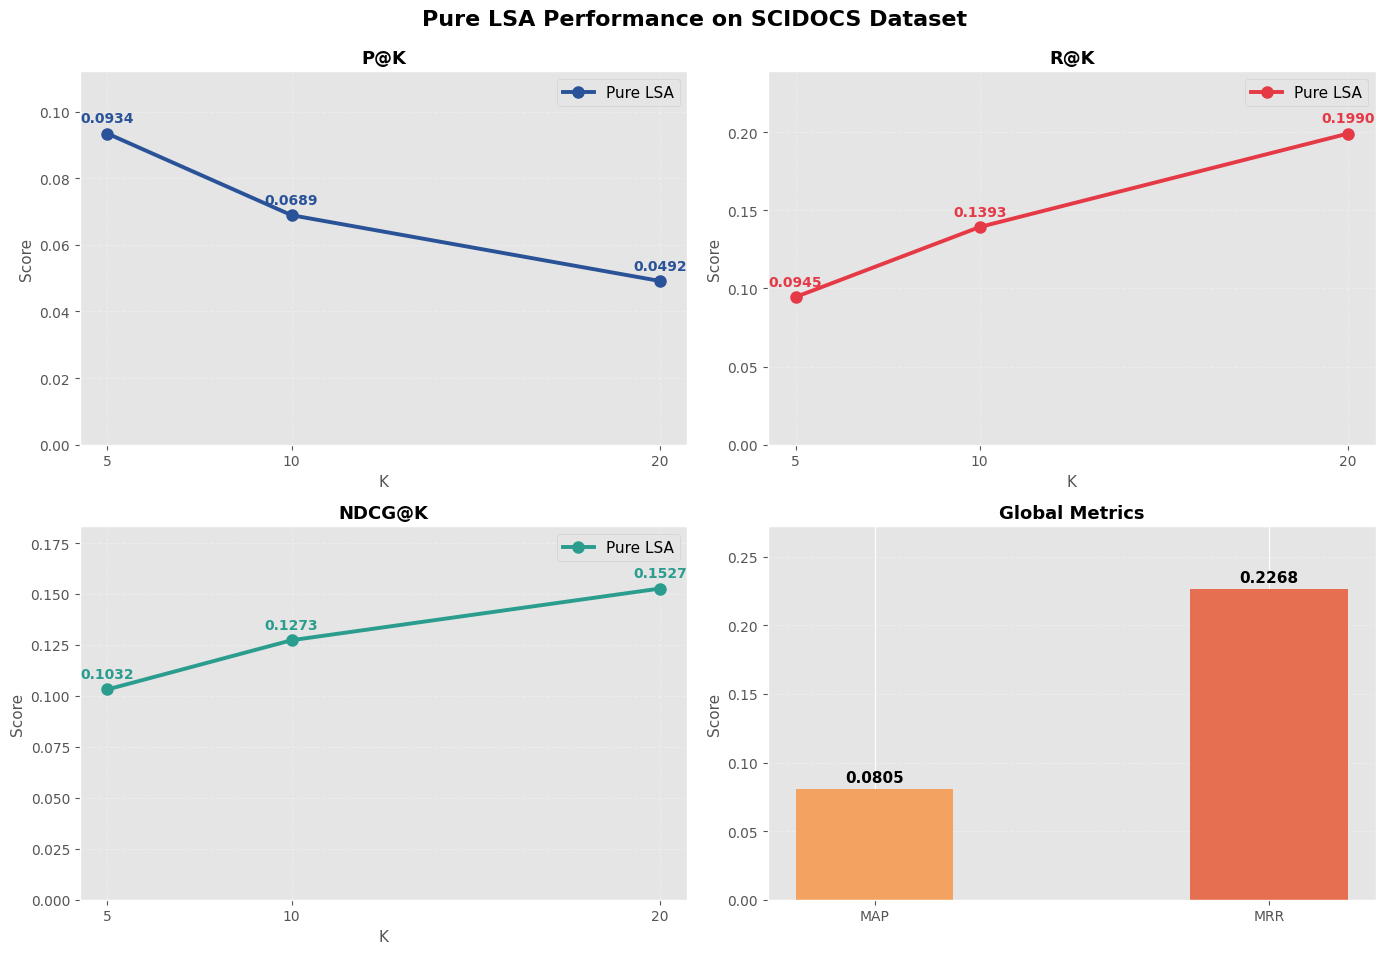

Đã lưu biểu đồ tại: ../data/processed\tv2/pure_lsa_performance_chart.png


In [8]:
# 8. Vẽ biểu đồ hiệu suất
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Pure LSA Performance on SCIDOCS Dataset', 
             fontsize=16, fontweight='bold', y=0.95)

# Danh sách các độ đo phụ thuộc vào K
k_metrics = ['P', 'R', 'NDCG']
k_vals = [5, 10, 20]
colors = ['#2a5298', '#e63946', '#2a9d8f']

# 1. Vẽ 3 biểu đồ đường cho P@K, R@K, NDCG@K
for ax, metric, color in zip(axes.flatten()[:3], k_metrics, colors):
    vals = [summary[f'{metric}@{k}'] for k in k_vals]
    
    # Vẽ đường
    ax.plot(k_vals, vals, label='Pure LSA', color=color, 
            linewidth=2.8, marker='o', markersize=8, linestyle='-')
    
    # Hiển thị giá trị trên từng điểm
    for k, v in zip(k_vals, vals):
        ax.annotate(f'{v:.4f}', xy=(k, v), xytext=(0, 8),
                    textcoords='offset points', ha='center',
                    fontsize=10, fontweight='bold', color=color)
    
    ax.set_title(f'{metric}@K', fontweight='bold', fontsize=13)
    ax.set_xlabel('K', fontsize=11)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_xticks(k_vals)
    ax.set_ylim(bottom=0, top=max(vals)*1.2 if max(vals) > 0 else 1)
    ax.grid(alpha=0.3, linestyle='--')
    ax.legend(fontsize=11)

# 2. Vẽ biểu đồ cột cho MAP và MRR)\ 
ax4 = axes[1, 1]
global_metrics = ['MAP', 'MRR']
global_vals = [summary['AP'], summary['MRR']] 
bars = ax4.bar(global_metrics, global_vals, color=['#f4a261', '#e76f51'], width=0.4)

# Hiển thị giá trị trên đỉnh cột
for bar in bars:
    yval = bar.get_height()
    ax4.annotate(f'{yval:.4f}', xy=(bar.get_x() + bar.get_width() / 2, yval), 
                 xytext=(0, 5), textcoords='offset points', ha='center', 
                 fontsize=11, fontweight='bold', color='black')

ax4.set_title('Global Metrics', fontweight='bold', fontsize=13)
ax4.set_ylabel('Score', fontsize=11)
ax4.set_ylim(bottom=0, top=max(global_vals)*1.2 if max(global_vals) > 0 else 1)
ax4.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout(rect=[0, 0, 1, 0.96])
chart_path = f"{TV2_OUT}/pure_lsa_performance_chart.png"
plt.savefig(chart_path, dpi=200, bbox_inches='tight')
plt.show()

print(f"Đã lưu biểu đồ tại: {chart_path}")

In [9]:
# 9. Tìm kiếm với Pure LSA và hiển thị kết quả
def search_pure_lsa(engine, query, top_k=10):
    # Tiền xử lý câu query
    q_proc = clean_text_for_lsa(query) 
    if not q_proc: 
        return pd.DataFrame() 
    
    # Ép Query sang không gian LSA
    q_tfidf = engine.vectorizer.transform([q_proc])
    q_lsa = engine.svd.transform(q_tfidf)
    q_lsa = normalize(q_lsa, axis=1) 
    
    # Tính điểm thuần túy bằng Cosine Similarity trong không gian LSA
    scores_lsa = np.dot(q_lsa, engine.lsa_matrix.T).flatten()
    
    # Lấy top_k kết quả cao nhất
    nonzero_idx = scores_lsa.nonzero()[0]
    if len(nonzero_idx) == 0: 
        return pd.DataFrame()
        
    best_idx = np.argsort(scores_lsa)[::-1][:top_k]
    
    # Trích xuất kết quả
    res_cols = ['_id', 'title', 'text'] if 'text' in engine.df.columns else ['_id', 'title']
    res = engine.df.iloc[best_idx][res_cols].copy()
    res['score'] = scores_lsa[best_idx].round(4)
    res['method'] = 'Pure LSA'
    
    return res.reset_index(drop=True)

def print_lsa_results(res: pd.DataFrame, top: int = 5):
    if res is None or res.empty:
        print("  [Không tìm thấy kết quả phù hợp]")
        return
        
    for _, row in res.head(top).iterrows():
        title = str(row['title']).replace('\n', ' ')
        print(f"  [{row['score']:.4f}] {title[:65]}...")

# Danh sách các câu truy vấn mẫu của SCIDOCS
TEST_QUERIES = [
    "citation recommendation scientific papers",
    "information retrieval neural network",
    "graph based document ranking",
    "biomedical text classification",
    "knowledge graph embedding",
]

# Chạy test qua từng câu truy vấn
print("=== KẾT QUẢ TÌM KIẾM MẪU VỚI PURE LSA ===")
for q in TEST_QUERIES:
    print(f"\n  Query: \"{q}\"")
    print(f"  LSA")
    res_df = search_pure_lsa(lsa_engine, q, top_k=5) 
    print_lsa_results(res_df, top=5)

=== KẾT QUẢ TÌM KIẾM MẪU VỚI PURE LSA ===

  Query: "citation recommendation scientific papers"
  LSA
  [0.7214] RefSeer: A citation recommendation system...
  [0.6172] Worthiness of Sentences in Scientific Reports...
  [0.5914] Recommending citations with translation model...
  [0.5903] Recommending citations for academic papers...
  [0.5773] Result Diversification in Automatic Citation Recommendation...

  Query: "information retrieval neural network"
  LSA
  [0.6183] Application of Spreading Activation Techniques in Information Ret...
  [0.6172] Introduction to Information Retrieval: Index...
  [0.5706] Topic models in information retrieval...
  [0.5565] Stemming of Amharic Words for Information Retrieval...
  [0.5504] An Association Thesaurus for Information Retrieval...

  Query: "graph based document ranking"
  LSA
  [0.7012] Centrality based Document Ranking...
  [0.5759] A Personalized Graph-Based Document Ranking Model Using a Semanti...
  [0.5413] A Sharp PageRank Algorithm w